<a href="https://colab.research.google.com/github/farhanh1418/mycodes/blob/Pythoncodes/Thermo_Mechanical_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
****Given (Meshing Code)****
---

**G_Mesh Import**

In [ ]:
try:
    import google.colab  # noqa: F401
except ImportError:
    import gmsh
else:
    try:
        import gmsh
    except ImportError:
        !wget "https://fem-on-colab.github.io/releases/gmsh-install.sh" -O "/tmp/gmsh-install.sh" && bash "/tmp/gmsh-install.sh"
        import gmsh

--2025-02-08 10:51:07--  https://fem-on-colab.github.io/releases/gmsh-install.sh
Resolving fem-on-colab.github.io (fem-on-colab.github.io)... 185.199.108.153, 185.199.109.153, 185.199.110.153, ...
Connecting to fem-on-colab.github.io (fem-on-colab.github.io)|185.199.108.153|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3497 (3.4K) [application/x-sh]
Saving to: ‘/tmp/gmsh-install.sh’

/tmp/gmsh-install.s 100%[===================>]   3.42K  --.-KB/s    in 0s      

2025-02-08 10:51:07 (34.6 MB/s) - ‘/tmp/gmsh-install.sh’ saved [3497/3497]

+ INSTALL_PREFIX=/usr/local
++ echo /usr/local
++ awk -F/ '{print NF-1}'
+ INSTALL_PREFIX_DEPTH=2
+ PROJECT_NAME=fem-on-colab
+ SHARE_PREFIX=/usr/local/share/fem-on-colab
+ GMSH_INSTALLED=/usr/local/share/fem-on-colab/gmsh.installed
+ [[ ! -f /usr/local/share/fem-on-colab/gmsh.installed ]]
+ H5PY_INSTALL_SCRIPT_PATH=https://github.com/fem-on-colab/fem-on-colab.github.io/raw/51750750/releases/h5py-install.sh
+ [[ https://gith

**Meshing**

In [ ]:
import gmsh

# Initialize Gmsh
gmsh.initialize()

# Create a new model
gmsh.model.add("L_shape_with_hole")

# Characteristic length for the mesh
lc = 0.05  # Adjust for finer or coarser mesh
e = 0.155 # Adjust thermal insulator layer thickness

# Define points for the L-shape (counter-clockwise)
gmsh.model.geo.addPoint(0, 0, 0, lc, 1)  # Bottom-left corner
gmsh.model.geo.addPoint(1, 0, 0, lc, 2)  # Bottom-right corner
gmsh.model.geo.addPoint(1, 0.4, 0, lc, 3)  # Inner corner (right)
gmsh.model.geo.addPoint(0.6, 0.4, 0, lc, 4)  # Inner corner (top)
gmsh.model.geo.addPoint(0.6, 1, 0, lc, 5)  # Top-right corner
gmsh.model.geo.addPoint(0, 1, 0, lc, 6)  # Top-left corner
gmsh.model.geo.addPoint(0, 1+e, 0, lc, 7)  # Top-left corner
gmsh.model.geo.addPoint(0.6, 1+e, 0, lc, 8)  # Top-left corner

# Define lines for the L-shape
gmsh.model.geo.addLine(1, 2, 1)  # Bottom edge
gmsh.model.geo.addLine(2, 3, 2)  # Right vertical edge (bottom)
gmsh.model.geo.addLine(3, 4, 3)  # Inner cut bottom edge
gmsh.model.geo.addLine(4, 5, 4)  # Right vertical edge (top)
gmsh.model.geo.addLine(5, 6, 5)  # Top edge
gmsh.model.geo.addLine(6, 1, 6)  # Left vertical edge
gmsh.model.geo.addLine(6, 7, 7)
gmsh.model.geo.addLine(5, 8, 8)
gmsh.model.geo.addLine(7, 8, 9)

# Define the disk
disk_center_x, disk_center_y, disk_radius = 0.3, 0.6, 0.2

# Add points for the disk
center_point = gmsh.model.geo.addPoint(disk_center_x, disk_center_y, 0, lc)
perimeter_point_1 = gmsh.model.geo.addPoint(disk_center_x + disk_radius, disk_center_y, 0, lc)
perimeter_point_2 = gmsh.model.geo.addPoint(disk_center_x, disk_center_y + disk_radius, 0, lc)
perimeter_point_3 = gmsh.model.geo.addPoint(disk_center_x - disk_radius, disk_center_y, 0, lc)
perimeter_point_4 = gmsh.model.geo.addPoint(disk_center_x, disk_center_y - disk_radius, 0, lc)

# Create the circle arcs
arc_1 = gmsh.model.geo.addCircleArc(perimeter_point_1, center_point, perimeter_point_2)
arc_2 = gmsh.model.geo.addCircleArc(perimeter_point_2, center_point, perimeter_point_3)
arc_3 = gmsh.model.geo.addCircleArc(perimeter_point_3, center_point, perimeter_point_4)
arc_4 = gmsh.model.geo.addCircleArc(perimeter_point_4, center_point, perimeter_point_1)

# Define curve loops
outer_loop_L = gmsh.model.geo.addCurveLoop([1, 2, 3, 4, 5, 6])  # L-shape outer boundary
inner_loop_disk = gmsh.model.geo.addCurveLoop([arc_1, arc_2, arc_3, arc_4])  # Disk boundary
outer_loop_insulator = gmsh.model.geo.addCurveLoop([-5, 8, -9, -7])

# Define the plane surfaces
gmsh.model.geo.addPlaneSurface([outer_loop_L, inner_loop_disk], 1)  # L-shape with hole
gmsh.model.geo.addPlaneSurface([inner_loop_disk], 2)  # Disk (filled)
gmsh.model.geo.addPlaneSurface([outer_loop_insulator], 3)

# Synchronize the model
gmsh.model.geo.synchronize()

# Set up physical groups
gmsh.model.addPhysicalGroup(2, [1], 1)  # Physical group for the L-shape
gmsh.model.setPhysicalName(2, 1, "L_Shape")
gmsh.model.addPhysicalGroup(2, [2], 2)  # Physical group for the disk
gmsh.model.setPhysicalName(2, 2, "Disk")
gmsh.model.addPhysicalGroup(2, [3], 3)  # Physical group for the insulator layer
gmsh.model.setPhysicalName(2, 3, "Insulator")

# Generate triangular mesh
gmsh.option.setNumber("Mesh.ElementOrder", 1)  # First-order triangles
gmsh.option.setNumber("Mesh.Algorithm", 6)    # Use Delaunay for triangle meshing
gmsh.model.mesh.generate(2)

# Save the mesh in .msh format
gmsh.write("L_shape_with_hole.msh")

# Finalize the Gmsh session
gmsh.finalize()


**Mesh Plot**

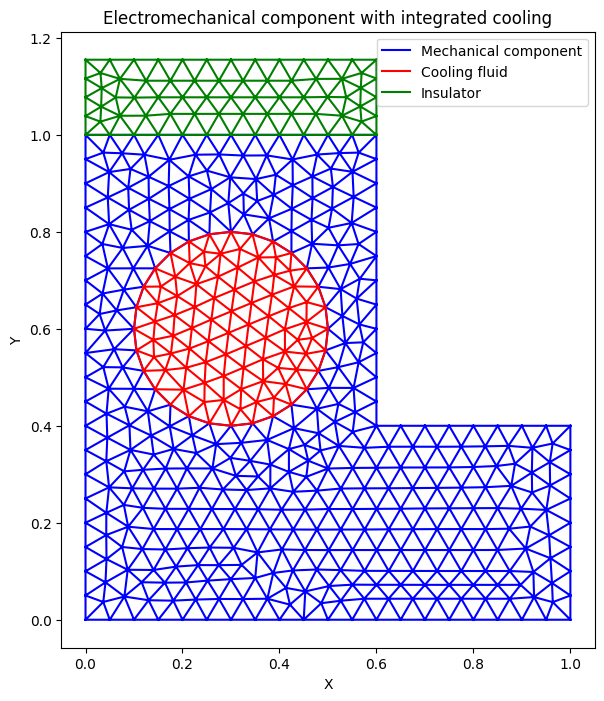

In [ ]:
import gmsh
import numpy as np
import matplotlib.pyplot as plt

# Initialize Gmsh and load the mesh
gmsh.initialize()
gmsh.open("L_shape_with_hole.msh")

# Get all nodes
node_tags, node_coords, _ = gmsh.model.mesh.getNodes()
node_coords = np.array(node_coords).reshape(-1, 3)

# Function to get elements of a physical group
def get_elements_of_physical_group(dim, tag):
    entity_tags = gmsh.model.getEntitiesForPhysicalGroup(dim, tag)
    all_elements = []
    for entity_tag in entity_tags:
        element_types, element_tags, node_tags = gmsh.model.mesh.getElements(dim, entity_tag)
        for i in range(len(element_types)):
            all_elements.append(np.array(node_tags[i]).reshape(-1, 3))
    return np.concatenate(all_elements) if all_elements else np.array([])

# Get elements for each physical surface
elements_surface_1 = get_elements_of_physical_group(2, 1)
elements_surface_2 = get_elements_of_physical_group(2, 2)
elements_surface_3 = get_elements_of_physical_group(2, 3)

# Plot the mesh for each physical surface separately
plt.figure(figsize=(8, 8))

# Plot for Physical Surface 1
if elements_surface_1.size > 0:
    plt.triplot(node_coords[:, 0], node_coords[:, 1], elements_surface_1 - 1, color='blue', label='Mechanical component')

# Plot for Physical Surface 2
if elements_surface_2.size > 0:
    plt.triplot(node_coords[:, 0], node_coords[:, 1], elements_surface_2 - 1, color='red', label='Cooling fluid')

# Plot for Physical Surface 3
if elements_surface_3.size > 0:
    plt.triplot(node_coords[:, 0], node_coords[:, 1], elements_surface_3 - 1, color='green', label='Insulator')

plt.gca().set_aspect('equal')
plt.title('Electromechanical component with integrated cooling')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()

# Finalize Gmsh
gmsh.finalize()

---
****Part 1 : Thermal Conduction Analysis****
---

**Jacobian**

This block is used to calculate the Jacobian determinant, which is then used for calculating element area and eventually stiffness, element force, and performing numerical analysis.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
nodes = np.delete(node_coords, 2, axis=1)
total_elements = elements_surface_1.shape[0] + elements_surface_2.shape[0] + elements_surface_3.shape[0]
  # compute the jacobian value for a triangle
  # coord is a (2x3) array
  # [[x1 x2 x3]
  #   y1 y2 y3]]
  # it's the determinant of the jacobian which

Jacobian = lambda coord: np.abs(((coord[0,0]-coord[0,2]) * (coord[1,1]-coord[1,2]) - (coord[0,1] - coord[0,2]) * (coord[1,0] - coord[1,2])))

N = nodes.shape[0] # global matrix size

**B_Matrix**

This function calculates a matrix that links temperature changes within a triangular element to temperature values at the nodes.

In [ ]:
def B_matrix(coord):
    B = [[coord[1,1]-coord[1,2],coord[1,2]-coord[1,0],coord[1,0]-coord[1,1]],
         [coord[0,2]-coord[0,1],coord[0,0]-coord[0,2],coord[0,1]-coord[0,0]]]
    return B / (Jacobian(coord))

**CST Function**

The CST function calculates the stiffness (K) and force (F) for every triangular element using material properties (k, Q), thickness (t), and previously defined functions (Jacobian, B_matrix). These values contribute to the build the Global stiffness matrix and Global F Vector.

In [ ]:
def CST (coord,k,Q): # k is thermal conductivity of the material
  t = 1 # t = thickness
  K=np.zeros((3,3))
  F=np.zeros((3,1))
  K = t*k*Jacobian(coord)/2*np.matmul(np.transpose(B_matrix(coord)),B_matrix(coord))
  F = 1/3*(t*Q*Jacobian(coord)/2)*np.ones(3)
  return K , F

**Global Stiffness Assembly**

This function assembles the global stiffness matrix (K) and force vector (F) for the entire system.
It does this by iterating through each element of a surface, calculating individual element contributions
using CST, and adding them to the global matrices. This process is repeated for each surface (1, 2, 3)
with their specific material properties, resulting in the final K and F used
for the application of boundary conditions and solving the equation for temperature.

In [ ]:

def KG(F,K,elements_surface,k,Q,node_coords):
  K = K.copy()
  F = F.copy()
  for element in elements_surface:
    coord = np.transpose(np.vstack((node_coords[int(element[0]-1)],node_coords[int(element[1]-1)],node_coords[int(element[2]-1)]))) #Getting the coordinates of each element to calculate the local stiffness matrix
    Ke, Fe = CST (coord,k,Q)
    for i in range(element.shape[0]):  #Loop responsible for placing the values from the local stiffness matrix to global one
      F[int(element[i]-1)] += Fe[i]
      for j in range(element.shape[0]):
        K[int(element[i]-1),int(element[j]-1)] += Ke[i,j]
  return K , F

K0 = np.zeros((N,N))
F0 = np.zeros((N,1))
C = np.zeros((N,N))


# For Surface 1
k = 100 # Conductivity
Q = 0  # Source
K1 , F1 = KG(F0,K0,elements_surface_1,k,Q,node_coords)
# print(K1)

# For Surface 2
k = 10 # Conductivity
Q = -1 # Source
K2 , F2 = KG(F1,K1,elements_surface_2,k,Q,node_coords)
# print(K2)

# For Surface 3
k = 1 # Conductivity
Q = 0 # Source
K3 , F3 = KG(F2, K2,elements_surface_3,k,Q,node_coords)
K = K3
F = F3
# print(K ,"\n\n", F)

**Checking the Global Stiffness Matrix**

This step is just to check if the assembeled matrix K is symmetric and its all eigen-values are positive.

In [ ]:
M = K - np.transpose(K)
if np.array_equal(M,C):
  print("Matrices are equal")
else:
  print("Matrices are not equal")
eigenvalues, eigenvectors = np.linalg.eigh(K)
def threshold_eigenvalues(eigenvalues, threshold=1e-10):
  """Converts eigenvalues close to zero to exactly zero."""
  thresholded_eigenvalues = [0 if abs(ev) < threshold else ev for ev in eigenvalues]
  return thresholded_eigenvalues

EVK = threshold_eigenvalues(eigenvalues)
EVK = np.array(EVK)

if np.any(EVK < 0):
  print("There are negative eigenvalues.")
else:
  print("All eigenvalues are positive.")

Matrices are equal
All eigenvalues are positive.


**Applying the Boundary Conditions and Solution**

This code section applies boundary conditions to the heat transfer problem and solves for the
temperature distribution (T). It identifies nodes on different boundaries, applies Dirichlet
boundary conditions (fixed temperature) using the apply_dirichlet_bc function, and then solves
the system of equations to obtain T. Finally, it calculates the total and top surface heat flux
to find the percentage of the flux passing through the top surface so insulator thickness can be optimized.

In [ ]:
# We need to get the nodes of all the boundaries of the plate
bottom_nodes = np.where(node_coords[:, 1] == 0)[0]
y_0_4_nodes = np.where((node_coords[:, 0] >= 0.6) & (node_coords[:, 1] == 0.4))[0]
right_top_nodes = np.where((node_coords[:, 0] == 0.6) & (node_coords[:, 1] >= 0.4))[0]
top_nodes = np.where(node_coords[:, 1] == round(1 + e,5))[0]
right_bottom_nodes = np.where(node_coords[:, 0] == 1)[0]
left_nodes = np.where(node_coords[:, 0] == 0)[0]

dirichlet_nodes = np.unique(np.concatenate([bottom_nodes,y_0_4_nodes,right_top_nodes,top_nodes])) # combining the nodes based on the BC type
neuman_nodes = np.unique(np.concatenate([right_bottom_nodes,left_nodes]))
# Apply BC

def apply_dirichlet_bc(K, F, dirichlet_nodes, temp):    # This loop applies the boundary constition on the respective nodes
    K = K.copy()
    F = F.copy()
    for node in dirichlet_nodes:
        F = F - K[:, node].reshape(-1, 1) * temp
        K[node, :] = 0
        K[:, node] = 0
        K[node, node] = 1
        F[node] = temp
    return K, F
K_bc, F_bc = apply_dirichlet_bc(K, F, dirichlet_nodes, temp=1)

# Solving for Temperatur
T = np.linalg.solve(K_bc, F_bc)
# print("Temperature distribution T:", T)

# Calculating flux

flux_q = np.matmul(K,T)
top_surface_flux = round(np.sum(flux_q[top_nodes]),5)
total_flux = round(np.sum(flux_q[dirichlet_nodes]),5)
print("total_flux:", total_flux, "W")
print("top_surface_flux:", top_surface_flux,"W")
print("\nWith an insulator thickness of", e,",", round(top_surface_flux/total_flux*100,2), "% of the total flux passes through the insulation.")

total_flux: 0.12461 W
top_surface_flux: 0.00123 W

With an insulator thickness of 0.155 , 0.99 % of the total flux passes through the insulation.


**Contour Plot of Temperature Distribution**

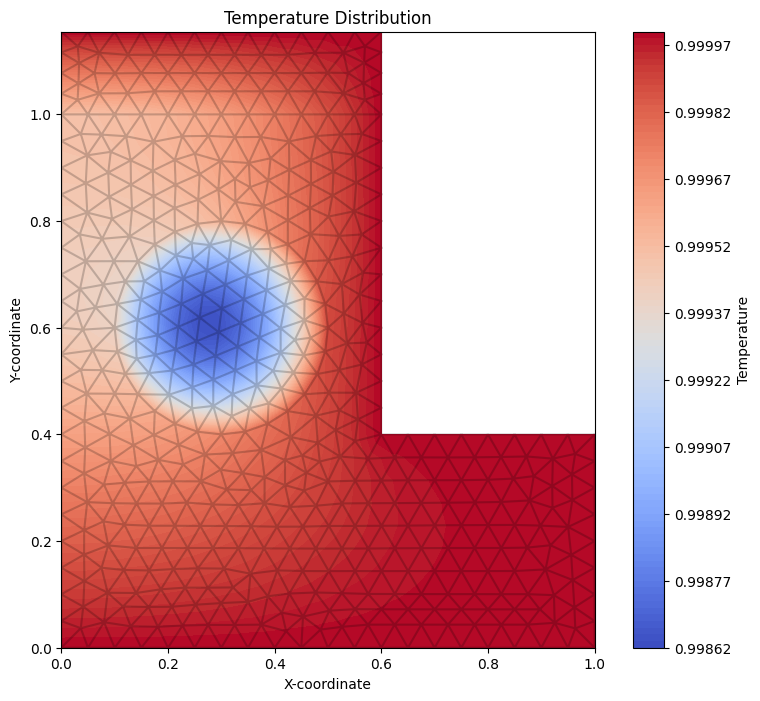

In [ ]:
import matplotlib.pyplot as plt

T = T.flatten()
node_coords_2d = node_coords[:, :2]
all_elements = np.vstack([elements_surface_1, elements_surface_2, elements_surface_3]) - 1
plt.figure(figsize=(10, 8))
contour = plt.tricontourf(node_coords_2d[:, 0], node_coords_2d[:, 1], all_elements, T, levels=100, cmap="coolwarm")
plt.colorbar(contour, label="Temperature")
plt.triplot(node_coords_2d[:, 0], node_coords_2d[:, 1], all_elements, color="black", alpha=0.2)
plt.title("Temperature Distribution")
plt.xlabel("X-coordinate")
plt.ylabel("Y-coordinate")
plt.gca().set_aspect("equal")
plt.show()


---
****Part 2 : Thermo-mechanical Analysis****
---

**Modified B Matrix for 2 DOFs**

This function calculates the strain-displacement matrix (B matrix) for a 2D plane strain element which relates the strains within an element to the displacements at its nodes. It is used to calculate the element stiffness matrix and force vector, which are then assembled into global matrices for solving the overall system.

In [ ]:
def B_matrix_2D(coord): # Modified matrix to account for x and y DOFs
    B = np.array([[coord[1,1]-coord[1,2], 0, coord[1,2]-coord[1,0], 0, coord[1,0]-coord[1,1], 0],
                  [0, coord[0,2]-coord[0,1], 0, coord[0,0]-coord[0,2], 0, coord[0,1]-coord[0,0]],
                  [coord[0,2]-coord[0,1], coord[1,1]-coord[1,2], coord[0,0]-coord[0,2], coord[1,2]-coord[1,0], coord[0,1]-coord[0,0], coord[1,0]-coord[1,1]]])

    return B / (Jacobian(coord))

**Modified CST Function**

The CST_2D function calculates the element stiffness matrix (K2D) and element force vector (F2D) for a 2D plane strain element. These are fundamental components in the Finite Element Method (FEM) used for solving structural problems, in this case, considering thermal effects as well. K2D represents the element's resistance to deformation, and F2D represents the forces acting on it due to thermal expansion. They are derived from material properties, geometry, and temperature changes and are essential for assembling the global system of equations to solve for displacements.

In [ ]:
def CST_2D(coord, E, nu,delta_T, alpha):  # calculation of local stifness matrix and force vector for 2-D analysis

    A = abs(Jacobian(coord)) / 2
    t = 1 #Thickness

    D = E * (1 - nu) / ((1 + nu) * (1 - 2 * nu)) * np.array([
                                                             [1, nu / (1 - nu), 0],
                                                             [nu / (1 - nu), 1, 0],
                                                            [0, 0, (1 - 2 * nu) / (2 * (1 - nu))]
                                                            ])

    B = B_matrix_2D(coord)
    K2D = t * A * np.dot(B.T, np.dot(D, B))

    strain_th = alpha * delta_T * np.array([[1], [1], [0]]) #Thermal Strain Calculation
    F2D = t * A * np.dot(B.T, np.dot(D, strain_th))

    return K2D, F2D

**Global Matrcies Assembly**

The KG_2D function assembles the global stiffness matrix (K) and force vector (F) for the 2D plane strain problem. It iterates through each element, calculates its stiffness and force contributions using CST_2D, and adds those contributions to the appropriate locations in the global matrices.

In [ ]:
def KG_2D(F, K, elements_surface, node_coords, E, nu, alpha, T, Initial_temp=1):

    F = F.copy()
    K = K.copy()

    # Delta T calculation
    for element in elements_surface:
        element_nodes = element - 1
        element_coords = node_coords[element_nodes, :2]
        delta_T = T[element_nodes].mean() - Initial_temp


        coord = np.array([
            [node_coords[int(element[0]-1)][0], node_coords[int(element[1]-1)][0], node_coords[int(element[2]-1)][0]],
            [node_coords[int(element[0]-1)][1], node_coords[int(element[1]-1)][1], node_coords[int(element[2]-1)][1]]
        ])

        # Calculation of element stiffness and force
        Ke, Fe = CST_2D(coord, E, nu,delta_T, alpha)


        # Addition of element values to the corresponding places in global matrices
        global_dofs = np.array([2*(int(element[0])-1), 2*(int(element[0])-1)+1,
                                2*(int(element[1])-1), 2*(int(element[1])-1)+1,
                                2*(int(element[2])-1), 2*(int(element[2])-1)+1])

        F[global_dofs,0] += Fe.flatten()
        K[np.ix_(global_dofs, global_dofs)] += Ke

    return K, F

K02D = np.zeros((2*N,2*N))
F02D = np.zeros((2*N,1))
C2D = np.zeros((2*N,2*N))

# For Surface 1
E1 = 2e11
nu1 = 0.3
alpha1 = 1e-5
K12D , F12D = KG_2D(F02D,K02D,elements_surface_1,node_coords,E1,nu1,alpha1,T)
# print(K1)

# For Surface 2
E2 = 2e11
nu2 = 0.49
alpha2 = 1e-6
K22D , F22D = KG_2D(F12D,K12D,elements_surface_2,node_coords,E2,nu2,alpha2,T)

# For Surface 3
E3 = 2e10
nu3 = 0.2
alpha3 = 1e-5
K32D , F32D = KG_2D(F22D,K22D,elements_surface_3,node_coords,E3,nu3,alpha3,T)
K = K32D
F = F32D
# print(K ,"\n\n", F)

NameError: name 'np' is not defined

**Boundary Consitions Application**

This function applies roller boundary conditions to the system. It identifies nodes on the bottom and left edges (roller supports), modifies the stiffness matrix (K) and force vector (F) to constrain displacement in specific directions while allowing movement in others, and then returns the updated matrices. These updated matrices are used to calculate the displacement od the nodes.

In [ ]:
# We need to get the nodes of the boundaries of the plate
def apply_roller_bc(K,F,node_coords):
    K = K.copy()
    bottom_nodes = np.where(node_coords[:, 1] == 0)[0]
    left_nodes = np.where(node_coords[:, 0] == 0)[0]

    for node in np.unique(np.concatenate([bottom_nodes, left_nodes])):
        x = 2 * node  # accessing the value of x-coordinates to apply the BC
        y = 2 * node + 1  # accessing the value of y-coordinates to apply the BC
        if node in bottom_nodes:
            K[y, :] = 0
            K[:, y] = 0
            K[y, y] = 1
            F[y] = 0
        if node in left_nodes:
            K[x, :] = 0
            K[:, x] = 0
            K[x, x] = 1
            F[x] = 0
    return K,F
K_bc, F_bc= apply_roller_bc(K,F, node_coords)

# print(K_bc,"\n",F_bc)

u = np.linalg.solve(K_bc, F)
# print(u)


**Displacement Distribution Plots**

In [ ]:
import matplotlib.tri as tri
node_coords_2d = node_coords[:, :2]
all_elements = np.vstack([elements_surface_1, elements_surface_2, elements_surface_3])
triangulation = tri.Triangulation(node_coords_2d[:, 0], node_coords_2d[:, 1], all_elements - 1)

ux = u[::2].flatten()
uy = u[1::2].flatten()
displacement_magnitude = np.sqrt(ux**2 + uy**2)

displacement_data = [ux, uy, displacement_magnitude]
displacement_labels = ["Displacement (ux)", "Displacement (uy)", "Displacement Magnitude"]
displacement_titles = ["Displacement Distribution (ux)", "Displacement Distribution (uy)", "Displacement Magnitude Distribution"]

for i in range(3):
    plt.figure(figsize=(10, 8))
    contour = plt.tricontourf(triangulation, displacement_data[i], levels=100, cmap='viridis')
    plt.colorbar(contour, label=displacement_labels[i])
    plt.triplot(triangulation, color="black", alpha=0.2)
    plt.title(displacement_titles[i])
    plt.xlabel("X-coordinate")
    plt.ylabel("Y-coordinate")
    plt.gca().set_aspect("equal")
    plt.show()

**Calculation of Strain from Displacements**

In [ ]:
strains = np.zeros((N, 3))

for surface_index, elements_surface in enumerate([elements_surface_1, elements_surface_2, elements_surface_3]):
    for element in elements_surface:
        element_nodes = element

        ux_local = u[2*(element_nodes-1)].flatten()
        uy_local = u[2*(element_nodes-1)+1].flatten()

        coord = np.array([
            [node_coords[int(element_nodes[0]-1)][0], node_coords[int(element_nodes[1]-1)][0], node_coords[int(element_nodes[2]-1)][0]],
            [node_coords[int(element_nodes[0]-1)][1], node_coords[int(element_nodes[1]-1)][1], node_coords[int(element_nodes[2]-1)][1]]
        ])

        B = B_matrix_2D(coord)
        for node_index, node in enumerate(element):
            node_int = int(node) - 1
            B_node = B[:, [2*node_index, 2*node_index+1]]

            strains[node_int, 0] = (B_node[0, 0] * ux_local[node_index] +
                                      B_node[0, 1] * uy_local[node_index])  # x component of strain
            strains[node_int, 1] = (B_node[1, 0] * ux_local[node_index] +
                                      B_node[1, 1] * uy_local[node_index])  # y component of strain
            strains[node_int, 2] = (B_node[2, 0] * ux_local[node_index] +
                                      B_node[2, 1] * uy_local[node_index])  # xy component of strain(Shear)

# print(strains)

**Calculation of Von Mises Stress**

In [ ]:
import matplotlib.colors as mcolors
stresses = np.zeros_like(strains)
def stress(strain, E, nu):
    #  plane strain condition
    stress = np.zeros_like(strain)
    stress[:, 0] = E / (1 - nu**2) * (strain[:, 0] + nu * strain[:, 1])  # sigma_xx
    stress[:, 1] = E / (1 - nu**2) * (strain[:, 1] + nu * strain[:, 0])  # sigma_yy
    stress[:, 2] = E / (2 * (1 + nu)) * strain[:, 2]  # sigma_xy (Shear)
    return stress

for i in range(strains.shape[0]):
    node_index = i
    if node_index in elements_surface_1.flatten() -1:
        E, nu = E1, nu1
    elif node_index in elements_surface_2.flatten() -1 :
        E, nu = E2, nu2
    elif node_index in elements_surface_3.flatten() -1:
        E, nu = E3, nu3
    else:
        E, nu = E1, nu1

    stresses[i, :] = stress(strains[i, :].reshape(1, -1), E, nu).flatten()

von_mises_stress = np.sqrt(0.5 * ((stresses[:, 0] - stresses[:, 1])**2 +
                                   (stresses[:, 1] - stresses[:,0])**2+
                                  (stresses[:,0])**2 +
                                  3 * stresses[:, 2]**2))

# Plot von Mises stress
colors = [(0, 0, 1), (0, 1, 1), (0, 1, 0), (1, 1, 0), (1, 0, 0)]
nodes = [0.0, 0.25, 0.5, 0.75, 1.0]
cmap_name = 'blue_red_smooth'
cm = mcolors.LinearSegmentedColormap.from_list(cmap_name, list(zip(nodes, colors)))

plt.figure(figsize=(10, 8))
contour = plt.tricontourf(triangulation, von_mises_stress, levels=100, cmap=cm)
plt.colorbar(contour, label="Von Mises Stress")
plt.triplot(triangulation, color="black", alpha=0.2)
plt.title("Von Mises Stress Distribution")
plt.xlabel("X-coordinate")
plt.ylabel("Y-coordinate")
plt.gca().set_aspect("equal")
plt.show()
